# 🚀 Qwen3-VL-32B + Qwen3.5-27B 듀얼 모델 앙상블 (Colab A100 90GB)

**재활용품 이미지 기반 VQA — 듀얼 모델 소프트 앙상블**

| 항목 | Model A (Qwen3-VL-32B) | Model B (Qwen3.5-27B) |
|---|---|---|
| 모델 | Qwen3-VL-32B-Instruct | Qwen3.5-27B |
| 역할 | LoRA Fine-tuned (체크포인트) | LoRA Fine-tuned (새로 학습) |
| 아키텍처 | Qwen3-VL | Gated DeltaNet + Gated Attention |
| 특징 | 재활용 도메인 최적화 | CountBench 97.8%, 201개 언어 |

**전략:**
1. Model A: 기존 체크포인트 로드 → 추론만
2. Model B: Qwen3.5-27B LoRA 파인튜닝 → 추론
3. 두 모델의 logit 확률 가중 앙상블 → 최종 CSV 제출

**환경:** Google Colab A100 90GB VRAM

## 1. 환경 설정

In [1]:
# ===== 필수 패키지 설치 =====
# Qwen3.5는 transformers v5 (main branch) 필요
!pip install -q --upgrade pip
!pip install -q "transformers @ git+https://github.com/huggingface/transformers.git@main"
!pip install -q --upgrade accelerate bitsandbytes peft trl
!pip install -q qwen-vl-utils albumentations scikit-learn seaborn
!pip install -q unsloth

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name}")
    print(f"VRAM: {props.total_memory / 1024**3:.1f} GB")
    print(f"BF16: {torch.cuda.is_bf16_supported()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 34.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM: 95.0 GB
BF16: True


## 2. Google Drive 마운트 & 경로 설정

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

# ===== 경로 설정 — 본인 환경에 맞게 수정 =====
DATA_ROOT = "/content/drive/MyDrive/Colab Notebooks/"
TRAIN_CSV = os.path.join(DATA_ROOT, "train.csv")
DEV_CSV   = os.path.join(DATA_ROOT, "dev.csv")
TEST_CSV  = os.path.join(DATA_ROOT, "test.csv")
IMAGE_ROOT = DATA_ROOT

# 체크포인트 경로
MODEL_A_CKPT = "/content/drive/MyDrive/checkpoint_best"  # Qwen3-VL-32B LoRA 체크포인트
MODEL_B_SAVE_DIR = "/content/drive/MyDrive/checkpoint_qwen35_27b"  # Qwen3.5-27B 저장 경로

# 확인
for name, path in [("Train", TRAIN_CSV), ("Dev", DEV_CSV), ("Test", TEST_CSV)]:
    print(f"{'✅' if os.path.exists(path) else '❌'} {name}: {path}")
print(f"{'✅' if os.path.exists(MODEL_A_CKPT) else '❌'} Model A checkpoint: {MODEL_A_CKPT}")

✅ Train: /content/drive/MyDrive/Colab Notebooks/train.csv
✅ Dev: /content/drive/MyDrive/Colab Notebooks/dev.csv
✅ Test: /content/drive/MyDrive/Colab Notebooks/test.csv
✅ Model A checkpoint: /content/drive/MyDrive/checkpoint_best


## 3. 라이브러리 및 공통 설정

In [4]:
import os, re, math, random, glob, gc
import numpy as np
import pandas as pd
from PIL import Image
from collections import Counter
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

Image.MAX_IMAGE_PIXELS = None
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ===== 시드 고정 =====
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ===== 모델 ID =====
MODEL_A_ID = "Qwen/Qwen3-VL-32B-Instruct"  # Model A 베이스
MODEL_B_ID = "Qwen/Qwen3.5-27B"             # Model B (새로 학습)

MAX_SEQ_LENGTH = 2048
MAX_NEW_TOKENS = 2

Device: cuda


## 4. 데이터 로드 및 시각화

Dev: 4413
Train: 5073, Test: 5074
Train images found: 5073 / 5073


/tmp/ipykernel_4325/958241453.py:59: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4325/958241453.py:59: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4325/958241453.py:59: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4325/958241453.py:59: UserWarning: Glyph 55152 (\N{HANGUL SYLLABLE HYIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4325/958241453.py:59: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4325/958241453.py:59: UserWarning: Glyph 53568 (\N{HANGUL SYLLABLE TEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4325/958241453.py:59: UserWarning: Glyph 48660 (\N{HANGUL SYLLABLE BEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layou

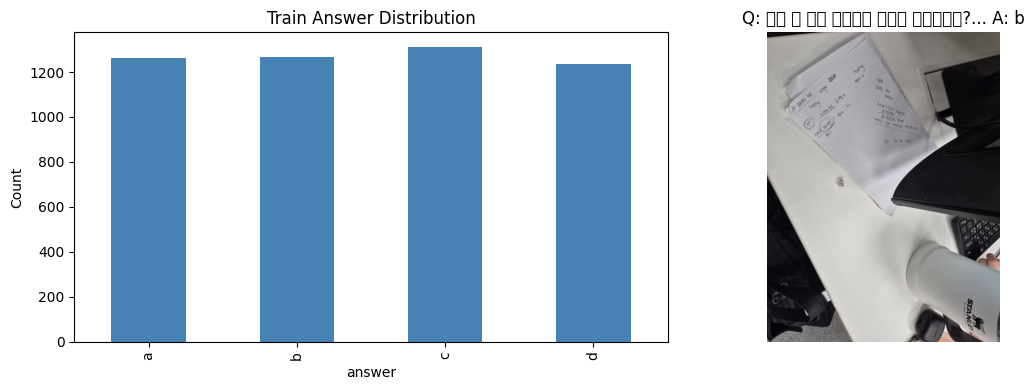

In [5]:
# ===== 데이터 로드 =====
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

# dev.csv: answer1~5 → 다수결
if os.path.exists(DEV_CSV):
    dev_df = pd.read_csv(DEV_CSV)
    def majority_vote(row):
        votes = [row.get(f"answer{i}", row.get(f"응답 {i}", None)) for i in range(1, 6)]
        votes = [v for v in votes if v is not None and pd.notna(v)]
        if not votes:
            return "a"
        return Counter(votes).most_common(1)[0][0]
    # 응답 컬럼명 자동 감지
    answer_cols = [c for c in dev_df.columns if "answer" in c.lower() or "응답" in c]
    if answer_cols:
        dev_df["answer"] = dev_df.apply(majority_vote, axis=1)
        dev_df = dev_df.drop(columns=answer_cols)
    print(f"Dev: {len(dev_df)}")
else:
    dev_df = None
    print("⚠️ dev.csv not found, skipping")

print(f"Train: {len(train_df)}, Test: {len(test_df)}")

# 경로 보정
def fix_path(p):
    if os.path.isabs(p) and os.path.exists(p):
        return p
    candidate = os.path.join(DATA_ROOT, p)
    if os.path.exists(candidate):
        return candidate
    return p

train_df["path"] = train_df["path"].astype(str).apply(fix_path)
test_df["path"]  = test_df["path"].astype(str).apply(fix_path)
if dev_df is not None:
    dev_df["path"] = dev_df["path"].astype(str).apply(fix_path)

exist_count = train_df["path"].apply(os.path.exists).sum()
print(f"Train images found: {exist_count} / {len(train_df)}")

# 시각화
vc = train_df["answer"].value_counts().sort_index()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
vc.plot(kind="bar", ax=ax1, color="steelblue")
ax1.set_title("Train Answer Distribution")
ax1.set_ylabel("Count")

# 샘플 이미지
for i in range(min(4, len(train_df))):
    row = train_df.iloc[i]
    if os.path.exists(row["path"]):
        img = Image.open(row["path"]).convert("RGB")
        ax2.imshow(img)
        ax2.set_title(f"Q: {row['question'][:30]}... A: {row['answer']}")
        ax2.axis("off")
        break
plt.tight_layout()
plt.show()

## 5. 질문 유형 분류 + 프롬프트

질문 유형별로 최적화된 프롬프트를 사용합니다:
- **counting**: 개수 관련 질문
- **material**: 재질/소재 관련 질문
- **general**: 기타 일반 질문

In [6]:
# =====================================================================
# 질문 유형 분류기
# =====================================================================
def classify_question_type(question: str) -> str:
    q = question.strip()
    count_patterns = [
        r'몇\s*개', r'몇\s*병', r'몇\s*캔', r'몇\s*장', r'몇\s*권',
        r'개수', r'수량', r'총\s*몇', r'모두\s*몇', r'얼마나\s*많',
        r'몇\s*가지', r'몇\s*종류', r'몇\s*봉지', r'몇\s*컵', r'몇\s*조각', r'몇\s*통',
    ]
    for p in count_patterns:
        if re.search(p, q): return "counting"
    material_ask = [r'재질', r'소재', r'재료', r'무엇으로\s*만들', r'어떤\s*재', r'어떤\s*소재']
    for p in material_ask:
        if re.search(p, q): return "material"
    return "general"

# =====================================================================
# 시스템 프롬프트 (공용)
# =====================================================================
SYSTEM_INSTRUCT = (
    "You are an expert visual analysis AI specialized in recycling and waste classification.\n"
    "Your capabilities include:\n"
    "1. Precise identification of recyclable materials (plastic, glass, metal, paper, etc.)\n"
    "2. Counting and distinguishing items in waste/recycling images\n"
    "3. Recognizing packaging types, labels, and material compositions\n\n"
    "OUTPUT REQUIREMENTS:\n"
    "- Return exactly one lowercase letter (a, b, c, or d)\n"
    "- No other text, punctuation, or explanations\n\n"
    "QUALITY STANDARDS:\n"
    "1. Examine all visual details thoroughly, including material textures and labels\n"
    "2. Consider the specific context of recycling classification standards\n"
    "3. Evaluate all options systematically\n"
    "4. Choose the single most accurate answer based on visual evidence"
)

SYSTEM_COUNTING = (
    "You are a visual counting and analysis AI. "
    "Count items precisely by examining the entire image systematically. "
    "Return exactly one lowercase letter (a, b, c, or d). No explanations."
)

SYSTEM_MATERIAL = (
    "You are a materials identification AI specialized in recycling. "
    "Identify material types by examining textures, transparency, weight cues, and labels. "
    "Return exactly one lowercase letter (a, b, c, or d). No explanations."
)

SYSTEM_PROMPTS = {
    "general": SYSTEM_INSTRUCT,
    "counting": SYSTEM_COUNTING,
    "material": SYSTEM_MATERIAL,
}

# =====================================================================
# 프롬프트 빌더
# =====================================================================
def build_mc_prompt(question, a, b, c, d):
    return (
        f"QUESTION: {question}\n\n"
        f"OPTIONS:\n"
        f"a) {a}\nb) {b}\nc) {c}\nd) {d}\n\n"
        "Respond with exactly one letter (a, b, c, or d)."
    )

def build_counting_prompt(question, a, b, c, d):
    return (
        f"COUNTING TASK: {question}\n\n"
        f"OPTIONS:\na) {a}\nb) {b}\nc) {c}\nd) {d}\n\n"
        "Count carefully and respond with exactly one letter (a, b, c, or d)."
    )

def build_material_prompt(question, a, b, c, d):
    return (
        f"MATERIAL IDENTIFICATION: {question}\n\n"
        f"OPTIONS:\na) {a}\nb) {b}\nc) {c}\nd) {d}\n\n"
        "Identify the material and respond with exactly one letter (a, b, c, or d)."
    )

PROMPT_BUILDERS = {
    "general": build_mc_prompt,
    "counting": build_counting_prompt,
    "material": build_material_prompt,
}

print("✅ 프롬프트 정의 완료")
# 질문 유형 분포 확인
q_types = train_df["question"].apply(classify_question_type)
print(f"\nTrain 질문 유형 분포:\n{q_types.value_counts()}")

✅ 프롬프트 정의 완료

Train 질문 유형 분포:
question
counting    1755
general     1693
material    1625
Name: count, dtype: int64


## 6. Model B — Qwen3.5-27B LoRA 파인튜닝

Qwen3.5-27B를 Unsloth로 LoRA 파인튜닝합니다.
- bf16 LoRA VRAM: ~56GB (A100 90GB에서 충분)
- `transformers v5` 필수
- thinking mode OFF (`enable_thinking=False`)

In [7]:
# ===== Qwen3.5-27B Unsloth 로드 =====
from unsloth import FastModel

model_b, tokenizer_b = FastModel.from_pretrained(
    model_name="unsloth/Qwen3.5-27B",
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=False,      # Qwen3.5는 QLoRA 비권장, bf16 LoRA 사용
    load_in_16bit=True,
    full_finetuning=False,
)

# LoRA 어댑터
model_b = FastModel.get_peft_model(
    model_b,
    finetune_vision_layers=True,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=16,
    lora_alpha=16,
    lora_dropout=0.0,
    bias="none",
    random_state=SEED,
    use_rslora=True,
    loftq_config=None,
    use_gradient_checkpointing="unsloth",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                     "gate_proj", "up_proj", "down_proj"],
)

model_b.print_trainable_parameters()
print("✅ Qwen3.5-27B LoRA 모델 로드 완료")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.2: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/1184 [00:00<?, ?it/s]

...

preprocessor_config.json:   0%|          | 0.00/336 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/20.0M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

Unsloth: Making `model.base_model.model.model.language_model` require gradients
trainable params: 79,691,776 || all params: 27,436,420,336 || trainable%: 0.2905
✅ Qwen3.5-27B LoRA 모델 로드 완료


## 7. Model B 학습 데이터 준비

In [8]:
from datasets import Dataset, concatenate_datasets
from trl import SFTTrainer, SFTConfig
from trl.trainer.sft_trainer import DataCollatorForVisionLanguageModeling
from transformers import AutoProcessor
import albumentations as A

processor_b = AutoProcessor.from_pretrained(MODEL_B_ID, trust_remote_code=True)
collator_b = DataCollatorForVisionLanguageModeling(processor_b)

# ===== 학습 데이터 합치기 (train + dev) =====
combined_df = train_df.copy()
if dev_df is not None and "answer" in dev_df.columns:
    combined_df = pd.concat([combined_df, dev_df], ignore_index=True)
    print(f"Combined: {len(combined_df)} (train + dev)")
else:
    print(f"Train only: {len(combined_df)}")

# HuggingFace Dataset 변환
raw_dataset = Dataset.from_pandas(combined_df)

# 이미지 로드
def resize_with_padding(img, target_size=512):
    img = img.copy()
    img.thumbnail((target_size, target_size), Image.LANCZOS)
    padded = Image.new("RGB", (target_size, target_size), (255, 255, 255))
    offset = ((target_size - img.width) // 2, (target_size - img.height) // 2)
    padded.paste(img, offset)
    return padded

def convert_to_rgb(example):
    try:
        img_path = example["path"]
        if not os.path.isabs(img_path):
            img_path = os.path.join(IMAGE_ROOT, img_path)
        example["decoded_image"] = resize_with_padding(Image.open(img_path).convert("RGB"))
    except Exception as e:
        print(f"Error loading image {example['path']}: {e}")
        example["decoded_image"] = Image.new("RGB", (512, 512), color='white')
    return example

raw_dataset = raw_dataset.map(convert_to_rgb, num_proc=4)

# 증강
augmentation = A.Compose([
    A.RandomResizedCrop(size=(384, 384), scale=(0.9, 1.0), ratio=(0.85, 1.15), p=1.0),
    A.ColorJitter(brightness=0.08, contrast=0.08, saturation=0.0, hue=0.0, p=0.4),
    A.CLAHE(clip_limit=2.5, tile_grid_size=(8, 8), p=0.3),
])

def augment_example(example):
    np_img = np.array(example["decoded_image"])
    augmented = augmentation(image=np_img)["image"]
    example["decoded_image"] = Image.fromarray(augmented)
    return example

augmented_dataset = raw_dataset.map(augment_example, num_proc=4)
raw_dataset = concatenate_datasets([raw_dataset, augmented_dataset])
print(f"Total training samples (with augmentation): {len(raw_dataset)}")

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

Combined: 9486 (train + dev)


Map (num_proc=4):   0%|          | 0/9486 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/9486 [00:00<?, ? examples/s]

Total training samples (with augmentation): 18972


In [9]:
# ===== 대화 형식 변환 (Qwen3.5 포맷) =====
def make_conversation_b(example):
    q_type = classify_question_type(str(example["question"]))
    sys_p = SYSTEM_PROMPTS[q_type]
    user_text = PROMPT_BUILDERS[q_type](
        str(example["question"]), str(example["a"]),
        str(example["b"]), str(example["c"]), str(example["d"])
    )
    gold = str(example["answer"]).strip().lower()

    messages = [
        {"role": "system", "content": [{"type": "text", "text": sys_p}]},
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": user_text}
        ]},
        {"role": "assistant", "content": [
            {"type": "text", "text": gold}
        ]}
    ]
    image_data = [example["decoded_image"]] if "decoded_image" in example else []
    return {"messages": messages, "images": image_data}

remove_cols = [c for c in raw_dataset.column_names
               if c not in ["messages", "images"]]

train_dataset_b = raw_dataset.map(
    make_conversation_b,
    remove_columns=remove_cols,
    num_proc=4,
)

# 검증셋 (원본 train의 마지막 10%)
val_size = int(len(train_df) * 0.1)
val_df = train_df.tail(val_size).copy()
val_raw = Dataset.from_pandas(val_df)
val_raw = val_raw.map(convert_to_rgb, num_proc=4)
val_dataset_b = val_raw.map(
    make_conversation_b,
    remove_columns=[c for c in val_raw.column_names if c not in ["messages", "images"]],
    num_proc=4,
)

print(f"Train dataset: {len(train_dataset_b)}")
print(f"Valid dataset: {len(val_dataset_b)}")

Map (num_proc=4):   0%|          | 0/18972 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/507 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/507 [00:00<?, ? examples/s]

Train dataset: 18972
Valid dataset: 507


## 8. Model B 학습

In [10]:
# ===== Qwen3.5-27B 학습 =====
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

from unsloth import FastModel as _FM
# Unsloth에서 FastModel은 텍스트용, FastVisionModel은 비전용
# Qwen3.5는 통합 VLM이므로 FastModel 사용

per_device_train_batch_size = 1
gradient_accumulation_steps = 16
effective_batch_size = per_device_train_batch_size * gradient_accumulation_steps
num_train_epochs = 1
learning_rate = 5e-5
total_train_steps = math.ceil((len(train_dataset_b) * num_train_epochs) / effective_batch_size)
eval_steps = max(1, math.ceil(total_train_steps / 4))
logging_steps = 10

os.makedirs(MODEL_B_SAVE_DIR, exist_ok=True)

print(f"Effective Batch Size: {effective_batch_size}")
print(f"Total Training Steps: {total_train_steps}")
print(f"Evaluation Steps: {eval_steps}")

trainer_b = SFTTrainer(
    model=model_b,
    tokenizer=tokenizer_b,
    train_dataset=train_dataset_b,
    eval_dataset=val_dataset_b,
    packing=True,
    data_collator=collator_b,
    args=SFTConfig(
        per_device_train_batch_size=per_device_train_batch_size,
        per_device_eval_batch_size=1,
        gradient_accumulation_steps=gradient_accumulation_steps,
        warmup_steps=max(1, int(total_train_steps * 0.05)),
        num_train_epochs=num_train_epochs,
        learning_rate=learning_rate,
        logging_steps=logging_steps,
        eval_strategy="steps",
        eval_steps=eval_steps,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="cosine",
        seed=SEED,
        output_dir=MODEL_B_SAVE_DIR,
        report_to="none",
        remove_unused_columns=False,
        dataset_kwargs={"skip_prepare_dataset": True},
        max_length=MAX_SEQ_LENGTH,
        save_strategy="steps",
        save_steps=eval_steps,
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        bf16=True,
        tf32=True,
        dataloader_num_workers=4,
        dataloader_pin_memory=True,
    ),
)

print("\n🚀 Qwen3.5-27B 학습 시작...")
trainer_b.train()
print("✅ 학습 완료!")

# 평가
final_eval = trainer_b.evaluate()
print(f"Evaluation: {final_eval}")

Effective Batch Size: 16
Total Training Steps: 1186
Evaluation Steps: 297


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046, 'bos_token_id': None}.



🚀 Qwen3.5-27B 학습 시작...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 18,972 | Num Epochs = 1 | Total steps = 1,186
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 16 x 1) = 16
 "-____-"     Trainable parameters = 79,691,776 of 27,436,420,336 (0.29% trained)


ValueError: Caught ValueError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 57, in fetch
    return self.collate_fn(data)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py", line 42, in __call__
    return self.torch_call(features)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py", line 774, in torch_call
    batch = pad_without_fast_tokenizer_warning(
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py", line 63, in pad_without_fast_tokenizer_warning


In [ ]:
# ===== Model B 저장 후 메모리 해제 =====
# best checkpoint 저장
trainer_b.save_model(os.path.join(MODEL_B_SAVE_DIR, "best"))
print(f"✅ Model B saved to: {MODEL_B_SAVE_DIR}/best")

# 메모리 해제
del model_b, tokenizer_b, trainer_b, processor_b, collator_b
del train_dataset_b, val_dataset_b, raw_dataset, augmented_dataset
torch.cuda.empty_cache()
gc.collect()
print("✅ Model B 학습 메모리 해제 완료")

## 9. 추론 유틸리티

답변 추출 + logit 확률 기반 추론 함수 정의

In [ ]:
# =====================================================================
# 답변 추출 유틸
# =====================================================================
def extract_choice(text, probs=None):
    if not text:
        if probs is not None: return 'abcd'[probs.argmax().item()]
        return random.choice(['a','b','c','d'])
    text = text.strip().lower()
    if text in ('a','b','c','d'): return text
    m = re.search(r'\b([abcd])\b', text)
    if m: return m.group(1)
    m = re.search(r'[\(\[\{<\s\-:]*([abcd])[\)\]\}>:.,\s]*$', text)
    if m: return m.group(1)
    if probs is not None: return 'abcd'[probs.argmax().item()]
    return random.choice(['a','b','c','d'])

def get_abcd_probs_generic(model, processor, img, sys_prompt, user_text, device,
                            enable_thinking=None):
    """범용 추론 함수: a/b/c/d softmax 확률 반환"""
    messages = [
        {"role": "system", "content": [{"type": "text", "text": sys_prompt}]},
        {"role": "user", "content": [
            {"type": "image", "image": img},
            {"type": "text", "text": user_text}
        ]},
    ]

    # Qwen3.5: enable_thinking 지원
    template_kwargs = {"tokenize": False, "add_generation_prompt": True}
    if enable_thinking is not None:
        template_kwargs["enable_thinking"] = enable_thinking

    text = processor.apply_chat_template(messages, **template_kwargs)
    inputs = processor(text=[text], images=[img], return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False,
            output_scores=True, return_dict_in_generate=True,
            eos_token_id=processor.tokenizer.eos_token_id,
        )

    gen_text = processor.batch_decode(
        out.sequences[:, inputs["input_ids"].shape[1]:],
        skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]

    probs = None
    if out.scores and len(out.scores) > 0:
        logits = out.scores[0][0]
        cids = {}
        for ch in 'abcd':
            ids = processor.tokenizer.encode(ch, add_special_tokens=False)
            if ids: cids[ch] = ids[-1]
        if len(cids) == 4:
            lv = torch.tensor([logits[cids[ch]].item() for ch in 'abcd'], dtype=torch.float32)
            probs = torch.softmax(lv, dim=0)

    choice = extract_choice(gen_text, probs)
    conf = probs['abcd'.index(choice)].item() if probs is not None else 1.0
    return choice, conf, probs

def check_distribution_health(preds):
    counts = Counter(preds)
    total = len(preds)
    print("\n🔍 Distribution Health Check:")
    for ch in 'abcd':
        r = counts.get(ch,0)/total
        s = "✅" if 0.15 <= r <= 0.35 else ("⚠️" if 0.10 <= r <= 0.40 else "🚨")
        print(f"  {s} {ch}: {counts.get(ch,0):4d} ({r*100:.1f}%)")

print("✅ 추론 유틸리티 정의 완료")

## 10. Phase 1 — Model A 추론 (Qwen3-VL-32B, 체크포인트)

기존에 학습된 Qwen3-VL-32B LoRA 체크포인트를 로드하고 전체 테스트 데이터에 대해 추론합니다.

In [ ]:
# ===== Model A 로드 (추론용) =====
from transformers import AutoProcessor, BitsAndBytesConfig
from transformers import Qwen3VLForConditionalGeneration
from peft import PeftModel

print("📥 Loading Model A: Qwen3-VL-32B + LoRA...")

# bf16으로 로드 (A100 90GB에서 가능)
base_a = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_A_ID,
    torch_dtype=torch.bfloat16,
    trust_remote_code=True,
    low_cpu_mem_usage=True,
)
model_a = PeftModel.from_pretrained(base_a, MODEL_A_CKPT, local_files_only=True)
model_a = model_a.to(device).eval()
proc_a = AutoProcessor.from_pretrained(MODEL_A_ID, trust_remote_code=True)
print("✅ Model A loaded")

# ===== 테스트 데이터 =====
test_df = pd.read_csv(TEST_CSV)
test_df["path"] = test_df["path"].astype(str).apply(fix_path)
print(f"Test samples: {len(test_df)}")

In [ ]:
# ===== Model A 전체 추론 =====
ENSEMBLE_THRESHOLD = 0.70
ENSEMBLE_THRESHOLD_COUNTING = 0.80

results_a = []  # (choice, conf, probs, q_type)

for i in tqdm(range(len(test_df)), desc="Model A Inference"):
    row = test_df.iloc[i]
    if not os.path.exists(row["path"]):
        results_a.append(("a", 0.0, None, "missing"))
        continue

    img = Image.open(row["path"]).convert("RGB")
    q = str(row["question"])
    a, b, c, d = str(row["a"]), str(row["b"]), str(row["c"]), str(row["d"])

    q_type = classify_question_type(q)
    sys_p = SYSTEM_PROMPTS[q_type]
    user_p = PROMPT_BUILDERS[q_type](q, a, b, c, d)

    choice, conf, probs = get_abcd_probs_generic(model_a, proc_a, img, sys_p, user_p, device)
    results_a.append((choice, conf, probs, q_type))

    if i < 5:
        print(f"  [{i}] type={q_type} ans={choice} conf={conf:.3f}")

# 불확실 샘플 식별
thresh_map = {"counting": ENSEMBLE_THRESHOLD_COUNTING}
uncertain_indices = []
for i, (ch, cf, pr, qt) in enumerate(results_a):
    th = thresh_map.get(qt, ENSEMBLE_THRESHOLD)
    if cf < th:
        uncertain_indices.append(i)

print(f"\n✅ Model A done.")
print(f"Uncertain samples for ensemble: {len(uncertain_indices)}/{len(test_df)} ({len(uncertain_indices)/len(test_df)*100:.1f}%)")
check_distribution_health([r[0] for r in results_a])

In [ ]:
# ===== Model A 메모리 해제 =====
del model_a, base_a, proc_a
torch.cuda.empty_cache()
gc.collect()
print("✅ Model A unloaded, VRAM freed")

## 11. Phase 2 — Model B 추론 (Qwen3.5-27B, 파인튜닝된)

파인튜닝된 Qwen3.5-27B를 로드하고, Model A에서 confidence가 낮은 샘플에 대해 추론합니다.

In [ ]:
# ===== Model B 로드 (추론용) =====
from transformers import AutoModelForImageTextToText

print("\n📥 Loading Model B: Qwen3.5-27B (fine-tuned)...")

# best checkpoint 찾기
best_ckpt = os.path.join(MODEL_B_SAVE_DIR, "best")
if not os.path.exists(best_ckpt):
    ckpt_dirs = sorted(glob.glob(os.path.join(MODEL_B_SAVE_DIR, "checkpoint-*")))
    best_ckpt = ckpt_dirs[-1] if ckpt_dirs else MODEL_B_SAVE_DIR
print(f"Using checkpoint: {best_ckpt}")

# Qwen3.5-27B 로드
from peft import PeftModel as PM2
base_b = AutoModelForImageTextToText.from_pretrained(
    MODEL_B_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
    low_cpu_mem_usage=True,
)
model_b_infer = PM2.from_pretrained(base_b, best_ckpt, local_files_only=True)
model_b_infer.eval()
proc_b = AutoProcessor.from_pretrained(MODEL_B_ID, trust_remote_code=True)
print(f"✅ Model B loaded. Params: {sum(p.numel() for p in model_b_infer.parameters()):,}")

In [ ]:
# ===== Model B 불확실 샘플 추론 =====
WEIGHT_A = 1.0   # Model A 가중치 (fine-tuned 도메인 모델)
WEIGHT_B = 0.8   # Model B 가중치 (범용 VLM)

results_b = {}
ensemble_changed = 0

for idx in tqdm(uncertain_indices, desc="Model B Ensemble"):
    row = test_df.iloc[idx]
    if not os.path.exists(row["path"]):
        continue

    img = Image.open(row["path"]).convert("RGB")
    q = str(row["question"])
    a, b, c, d = str(row["a"]), str(row["b"]), str(row["c"]), str(row["d"])

    q_type = classify_question_type(q)
    sys_p = SYSTEM_PROMPTS[q_type]
    user_p = PROMPT_BUILDERS[q_type](q, a, b, c, d)

    # Qwen3.5: enable_thinking=False
    choice_b, conf_b, probs_b = get_abcd_probs_generic(
        model_b_infer, proc_b, img, sys_p, user_p, device, enable_thinking=False
    )
    results_b[idx] = (choice_b, conf_b, probs_b)

print(f"\n✅ Model B inference done: {len(results_b)} samples")

## 12. 소프트 앙상블 + 제출 CSV 생성

In [ ]:
# ===== 소프트 앙상블: logit 확률 가중 합산 =====
final_preds = []
final_confs = []
question_types = []

for i in range(len(test_df)):
    ch_a, cf_a, pr_a, qt = results_a[i]
    question_types.append(qt)

    if i in results_b and pr_a is not None:
        ch_b, cf_b, pr_b = results_b[i]
        if pr_b is not None:
            # 가중 소프트 앙상블
            merged = WEIGHT_A * pr_a + WEIGHT_B * pr_b
            final_ch = 'abcd'[merged.argmax().item()]
            final_cf = (merged[merged.argmax().item()] / merged.sum()).item()

            if final_ch != ch_a:
                ensemble_changed += 1

            final_preds.append(final_ch)
            final_confs.append(final_cf)
        else:
            final_preds.append(ch_a)
            final_confs.append(cf_a)
    else:
        final_preds.append(ch_a)
        final_confs.append(cf_a)

# ===== 결과 =====
print(f"\n{'='*60}")
print(f"✅ Dual-Model Ensemble Complete!")
print(f"{'='*60}")

print(f"\n📊 Question Type Distribution:")
tc = Counter(question_types)
for t, c in tc.most_common():
    print(f"  {t}: {c} ({c/len(test_df)*100:.1f}%)")

print(f"\n📊 Ensemble Statistics:")
print(f"  Model B called: {len(uncertain_indices)}/{len(test_df)} ({len(uncertain_indices)/len(test_df)*100:.1f}%)")
print(f"  Answer changed by ensemble: {ensemble_changed}")
print(f"  Avg confidence: {sum(final_confs)/len(final_confs):.3f}")

check_distribution_health(final_preds)

# ===== 제출 파일 =====
submission = pd.DataFrame({"id": test_df["id"], "answer": final_preds})
sub_path = os.path.join(DATA_ROOT, "submission_dual_ensemble.csv")
submission.to_csv(sub_path, index=False)
print(f"\n✅ Saved: {sub_path}")
print("\n📊 Answer Distribution:")
print(submission["answer"].value_counts().sort_index())
print(f"Total: {len(submission)}")
print(submission.head(10))

## 13. 결과 분석 및 시각화

In [ ]:
# ===== 시각화 =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confidence 분포
axes[0].hist(final_confs, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=ENSEMBLE_THRESHOLD, color='red', linestyle='--', label=f'Threshold={ENSEMBLE_THRESHOLD}')
axes[0].set_title("Final Confidence Distribution")
axes[0].set_xlabel("Confidence")
axes[0].legend()

# 2. 질문 유형별 Confidence
tc_conf = {}
for t, c in zip(question_types, final_confs):
    if t not in tc_conf: tc_conf[t] = []
    tc_conf[t].append(c)
labels, data = [], []
for t in sorted(tc_conf.keys()):
    labels.append(f"{t}\n(n={len(tc_conf[t])})")
    data.append(tc_conf[t])
axes[1].boxplot(data, labels=labels)
axes[1].set_title("Confidence by Question Type")
axes[1].set_ylabel("Confidence")

# 3. 최종 답변 분포
ans_counts = submission["answer"].value_counts().sort_index()
axes[2].bar(ans_counts.index, ans_counts.values, color='coral', edgecolor='black')
axes[2].set_title("Final Answer Distribution")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

# Model A vs Ensemble 비교
a_only = [results_a[i][0] for i in range(len(test_df))]
changed = sum(1 for a, f in zip(a_only, final_preds) if a != f)
print(f"\n📊 Model A → Ensemble 변경된 샘플: {changed}/{len(test_df)}")
if changed > 0:
    print(f"\n변경된 샘플 (최대 20개):")
    cnt = 0
    for i, (a, f) in enumerate(zip(a_only, final_preds)):
        if a != f and cnt < 20:
            q = str(test_df.iloc[i]["question"])[:50]
            print(f"  [{i}] {results_a[i][3]:10s} | A={a} → Ensemble={f} | conf_A={results_a[i][1]:.3f} | Q: {q}")
            cnt += 1

## 14. 메모리 정리

모든 추론 완료 후 메모리를 정리합니다.

In [ ]:
# 최종 메모리 정리
try:
    del model_b_infer, base_b, proc_b
except:
    pass
torch.cuda.empty_cache()
gc.collect()

print("✅ 모든 작업 완료!")
print(f"\n📄 제출 파일: {sub_path}")
print(f"📊 총 샘플: {len(submission)}")

## 참고사항

**듀얼 모델 앙상블 전략:**
- Model A (Qwen3-VL-32B + LoRA): 재활용 데이터에 fine-tuned, 도메인 지식 최적화
- Model B (Qwen3.5-27B + LoRA): 새로 학습, CountBench 97.8%, 시각적 이해 최상위급
- 가중치: Model A = 1.0 (도메인 특화), Model B = 0.8 (범용)
- VRAM 관리: 순차 로드/언로드로 A100 90GB에서 실행 가능

**튜닝 파라미터:**
- `ENSEMBLE_THRESHOLD`: 0.70 (일반), 0.80 (개수형)
- `WEIGHT_A` / `WEIGHT_B`: 1.0 / 0.8 (조정 가능)
- threshold 높이면 더 많은 샘플에 앙상블 적용

**Qwen3.5-27B 특이사항:**
- 아키텍처: Gated DeltaNet + Gated Attention 하이브리드
- Thinking mode 기본 ON → `enable_thinking=False`로 비활성화 필수
- `transformers >= v5` (GitHub main branch) 필수
- QLoRA(4bit) 비권장 → bf16 LoRA 사용
- bf16 LoRA VRAM: ~56GB (A100 90GB 충분)

**문제 해결:**
- OOM 발생 시: `batch_size=1`, `max_seq_length=1024`로 줄이기
- Model B 학습 건너뛰기: `MODEL_B_SAVE_DIR` 경로에 이미 체크포인트가 있으면 바로 추론 가능